# 3. Second order trotter approximation

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import qiskit

from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
print("Qiskit version: ", qiskit.__version__)

Qiskit version:  2.2.3


In [31]:
%load_ext autoreload
%autoreload 2
    
from Ising_sim_helper.operators import (
    KET_00, KET_01, KET_10, KET_11,
    COMPUTATIONAL_BASIS, BASIS_LABELS,
    I, X, Y, Z, X0, X1, Z0, Z1,
    ZZ, MZ,
)
from Ising_sim_helper.dynamics import (
    build_hamiltonian,
    exact_state,
    expectation_value,
    state_fidelity,
    basis_probabilities,
    analytic_energy_spectrum,
)
from Ising_sim_helper.circuits import (
    first_order_trotter_circuit,
    second_order_trotter_circuit,
    statevector_from_circuit,
)

In [19]:
J = 1.0
h = 0.6
H = -J * ZZ - h * (X0 + X1)
theta_x_half = -0.7
theta_zz = -2.0

second_order_circuit = second_order_trotter_circuit(time=1.0, J=1.0, h=0.6, n_steps=1,)
print(second_order_circuit)

     ┌──────────┐         ┌──────────┐
q_0: ┤ Rx(-0.6) ├─■───────┤ Rx(-0.6) ├
     ├──────────┤ │ZZ(-2) ├──────────┤
q_1: ┤ Rx(-0.6) ├─■───────┤ Rx(-0.6) ├
     └──────────┘         └──────────┘


In [20]:
def second_order_trotter_circuit_by_hand(time, J, h):
    c = np.cos(h * time)
    s = np.sin(h * time)
    m = np.cos(J * time)
    n = np.sin(J * time)
    
    #phase_aligned = np.exp(1j * J * time)
    #phase_anti = np.exp(-1j * J * time)

    return np.array(
        [
            m * c**2 + 1j * n, # a00
            1j * m * c * s, # a01
            1j * m * c * s, # a10
            -1 * m * s**2,  # a11

        ],
        dtype=complex,
    )


psi_second_by_hand = second_order_trotter_circuit_by_hand(time, J=1.0, h=0.6)
psi_second = second_order_trotter_circuit(time, J=1.0, h=0.6, n_steps=1)


psi_second_qiskit = Statevector.from_instruction(psi_second).data

print("Hand calculation:")
print(psi_second_by_hand)

print("\nQiskit:")
print(psi_second_qiskit)

assert np.allclose(psi_second_by_hand, psi_second_qiskit)


Hand calculation:
[ 0.36804252+0.84147098j  0.        +0.25179143j  0.        +0.25179143j
 -0.17225979+0.j        ]

Qiskit:
[ 3.68042518e-01+8.41470985e-01j  4.10116672e-18+2.51791434e-01j
  0.00000000e+00+2.51791434e-01j -1.72259788e-01-1.32579571e-17j]


## 3.1 Convergence Comparasion

In [24]:
step_numbers = [1, 2, 4, 8, 16, 32]

psi_exact = exact_state(time=1.0, hamiltonian=H, initial_state=KET_00)

mz_exact = expectation_value(psi_exact, MZ)

czz_exact = expectation_value(psi_exact, ZZ)


infidelity_first = []
infidelity_second = []
mz_err_first = []
mz_err_second = []
czz_err_first = []
czz_err_second = []

for n_steps in step_numbers:
    
    first_circuit  = first_order_trotter_circuit(time = 1.0, J=J, h=h, n_steps=n_steps,)
    second_circuit = second_order_trotter_circuit(time=1.0, J=J, h=h, n_steps=n_steps,)
    
    psi_first_qiskit = Statevector.from_instruction(first_circuit).data
    psi_second_qiskit = Statevector.from_instruction(second_circuit).data
    
    fidelity_first = state_fidelity(
        psi_exact,
        psi_first_qiskit,
    )
    fidelity_second = state_fidelity(
        psi_exact,
        psi_second_qiskit,
    )
    
    mz_first_trotter = expectation_value(
        psi_first_qiskit,
        MZ,
    )
    mz_second_trotter = expectation_value(
        psi_second_qiskit,
        MZ,
    )
    czz_first_trotter = expectation_value(
        psi_first_qiskit, 
        ZZ
    )
    czz_second_trotter = expectation_value(
        psi_second_qiskit, 
        ZZ
    )
    
    infidelity_first.append(1.0-fidelity_first)
    infidelity_second.append(1.0-fidelity_second)
    mz_err_first.append(mz_first_trotter)
    mz_err_second.append(mz_second_trotter)
    czz_err_first.append(czz_first_trotter)
    czz_err_second.append(czz_second_trotter)

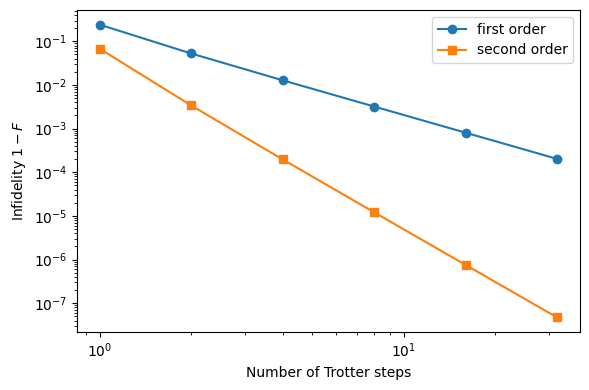

In [25]:
plt.figure(figsize=(6, 4))
plt.loglog(step_numbers, infidelity_first, marker='o', label='first order',)
plt.loglog(step_numbers, infidelity_second, marker='s', label='second order',)

plt.xlabel("Number of Trotter steps")
plt.ylabel(r"Infidelity $1-F$")
plt.legend()
plt.tight_layout()
plt.show()

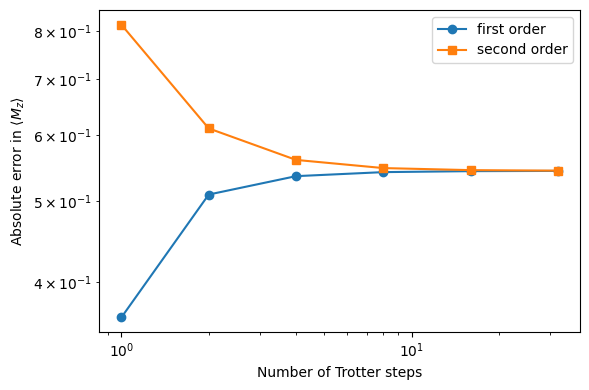

In [26]:
plt.figure(figsize=(6, 4))
plt.loglog(step_numbers, mz_err_first, marker='o', label='first order',)
plt.loglog(step_numbers, mz_err_second, marker='s', label='second order',)

plt.xlabel("Number of Trotter steps")
plt.ylabel(r"Absolute error in $\langle M_z\rangle$")
plt.legend()
plt.tight_layout()
plt.show()

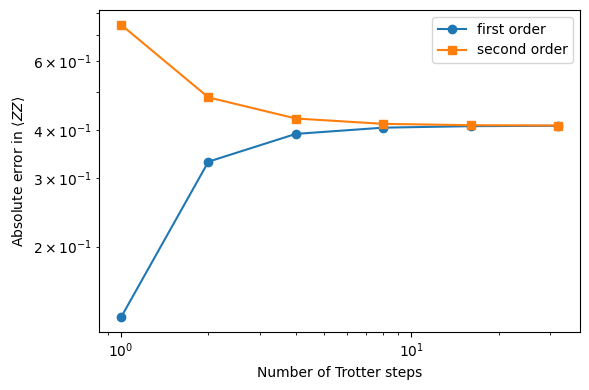

In [27]:
plt.figure(figsize=(6, 4))
plt.loglog(step_numbers, czz_err_first, marker='o', label='first order',)
plt.loglog(step_numbers, czz_err_second, marker='s', label='second order',)

plt.xlabel("Number of Trotter steps")
plt.ylabel(r"Absolute error in $\langle ZZ\rangle$")
plt.legend()
plt.tight_layout()
plt.show()

## 3.2 circuit cost

In [29]:
gate_count_first = []
gate_count_second = []

for n_steps in step_numbers:
    first_circuit =  first_order_trotter_circuit(time = 1.0, J=J, h=h, n_steps=n_steps,)
    second_circuit = second_order_trotter_circuit(time=1.0, J=J, h=h, n_steps=n_steps,)
    gate_count_first.append(first_circuit.size())
    gate_count_second.append(second_circuit.size())

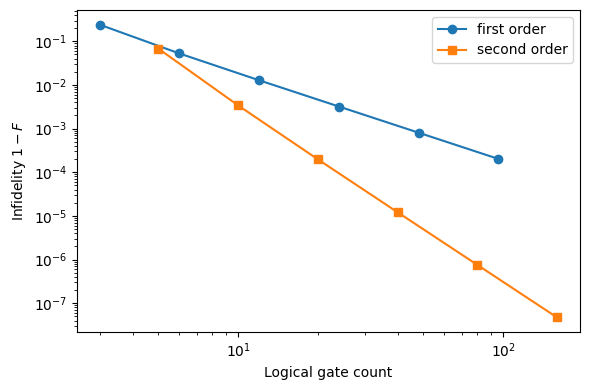

In [30]:
plt.figure(figsize=(6, 4))
plt.loglog(gate_count_first, infidelity_first, marker='o', label='first order',)
plt.loglog(gate_count_second, infidelity_second, marker='s', label='second order',)

plt.xlabel("Logical gate count")
plt.ylabel(r"Infidelity $1-F$")
plt.legend()
plt.tight_layout()
plt.show()